In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set seaborn style
sns.set(style="whitegrid")

# Load the Product Monthly Panel dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Display the first few rows
print("First five rows of the dataset:")
print(product_df.head())

First five rows of the dataset:
  product_id submission_time  rating  is_recommended  helpfulness  \
0    P107306      2008-09-30     4.0             NaN     0.883333   
1    P107306      2008-10-31     4.5             NaN     0.833333   
2    P107306      2008-11-30     1.0             NaN     0.833333   
3    P107306      2008-12-31     4.5             NaN     0.750000   
4    P107306      2009-01-31     5.0             NaN     0.833333   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                    15                         2                        13   
1                     6                         1                         5   
2                     6                         1                         5   
3                     6                         1                         5   
4                     8                         2                         6   

   price_usd brand_name  skin_tone eye_color    skin_type hair_color  
0      

In [7]:
# Selecting numerical features for clustering
numerical_cols = product_df.select_dtypes(include=[np.number]).columns
product_numeric = product_df[numerical_cols].dropna()


In [8]:
# Standardize the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)

In [9]:
# Finding optimal clusters using Elbow Method
wcss = []  # Within-cluster sum of squares
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(product_scaled)
    wcss.append(kmeans.inertia_)


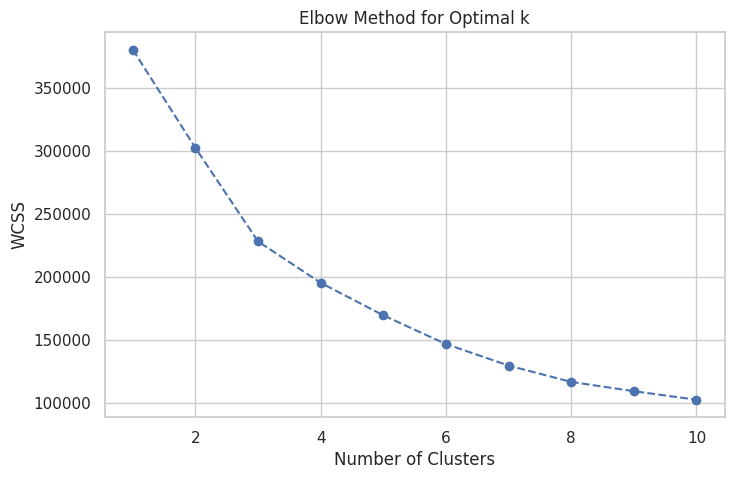

In [10]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


In [11]:
# Choosing k=3 (assumption; adjust based on the elbow plot)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
product_numeric['Cluster'] = kmeans.fit_predict(product_scaled)


In [12]:
# Reintegrate Clusters into the original DataFrame
product_df = product_df.loc[product_numeric.index]
product_df['Cluster'] = product_numeric['Cluster']



In [13]:
# Reducing dimensions for visualization using PCA
pca = PCA(n_components=2)
product_pca = pca.fit_transform(product_scaled)
product_df['PCA1'] = product_pca[:, 0]
product_df['PCA2'] = product_pca[:, 1]


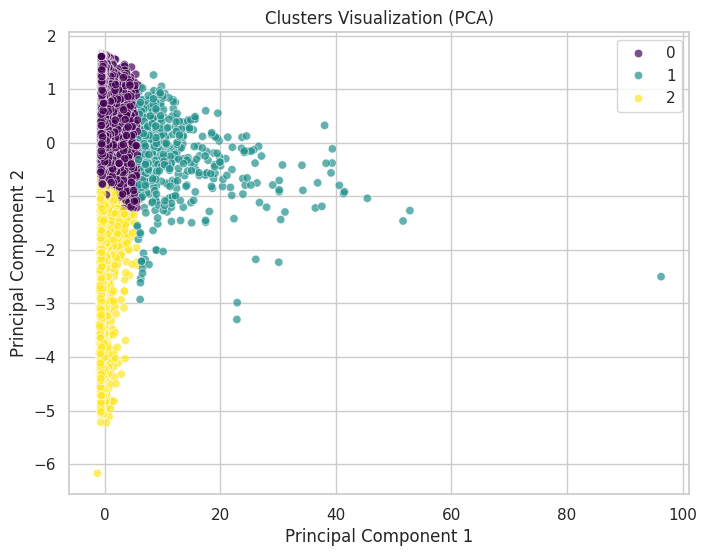


Cluster Counts:
Cluster
0    41345
2    12426
1      576
Name: count, dtype: int64


In [14]:
# Scatter plot of clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=product_df, palette='viridis', alpha=0.7)
plt.title('Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Display cluster counts
print("\nCluster Counts:")
print(product_df['Cluster'].value_counts())


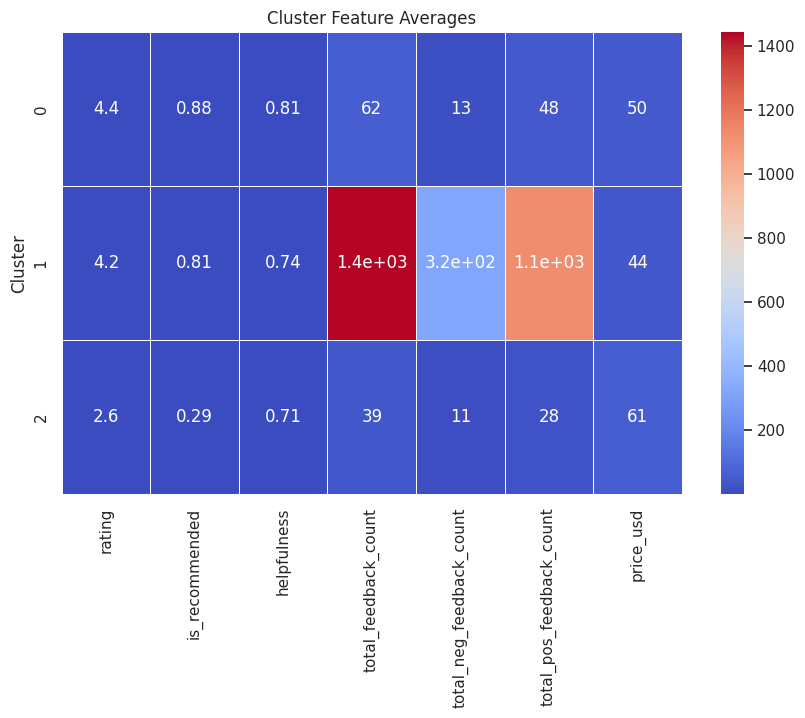

In [15]:
# Heatmap of cluster means
cluster_means = product_df.groupby('Cluster')[numerical_cols].mean()
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Feature Averages')
plt.show()